## Classification de Cibles Radars - Signaux Micro-Doppler

### Objectif

Construire et optimiser des réseaux de neurones convolutionnels capables d'identifier le type de cible en mouvement à partir de signatures micro-Doppler issues d'acquisitions radars réelles.

### Classes à prédire

* Vehicle
* Person
* Bicycle
* UAV (Drone)

### Configurations d'Entrée Étudiées

L'impact de la représentation mathématique du signal est évalué à travers 3 types d'inputs :

1. **Puissance (dB) :** Magnitude compressée en échelle logarithmique $\rightarrow$ Tenseur `[Batch, 1, 10, 1008]`
2. **Brut (Réel & Imaginaire) :** Composantes I/Q linéaires isolées $\rightarrow$ Tenseur `[Batch, 2, 10, 1008]`
3. **Physique (Module & Phase) :** Forme polaire exposant directement les gradients de vitesse $\rightarrow$ Tenseur `[Batch, 2, 10, 1008]`

### Approche

1. **Slicing temporel :** Découpage des trajectoires (*tracks*) de longueurs variables en fenêtres fixes de 10 spectres (0.5 s d'observation).
2. **Architecture Baseline :** Conception d'un réseau linéaire CNN 2D classique.
3. **Architecture Avancée (ResNet 2D) :** Implémentation de blocs résiduels dynamiques avec *Projection Shortcut* (convolution $1 \times 1$) pour gérer l'asymétrie temporelle/fréquentielle du signal.
4. **Optimisation du Pipeline :** Intégration du calcul sur GPU CUDA, régularisation (Dropout / Weight Decay), Checkpointing et Early Stopping.
5. **Analyse Comparative :** Étude de l'impact des représentations du signal et du tuning des hyperparamètres sur la capacité de généralisation du modèle.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import gdown
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim

In [2]:
# UTILISATION DU GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Le réseau va s'entraîner sur : {device}")

Le réseau va s'entraîner sur : cuda


In [3]:
# TELECHARGEMENT DATAS

file_id = "1CJyTqtCM4kOSQt2X7n2NgWCVEqou8RCB"

if not Path("moving_target_dataset.npy").exists():
    gdown.download(id=file_id)
else:
    print("Le fichier existe déjà.")

Le fichier existe déjà.


In [4]:
# CHARGEMENT DES DATAS

filename = "moving_target_dataset.npy"
datas = np.load(filename, allow_pickle=True)

In [5]:
# AFFICHAGE DES CLASSES

class_names = []
for acq in datas:
    if not any(acq['class_name'] in s for s in class_names):
        class_names.append(acq['class_name'])

print(class_names)

['vehicle', 'person', 'bicycle', 'uav']


In [6]:
# COMPTE DES CLASSES

Counter(acq["class_name"] for acq in datas)

Counter({'vehicle': 201, 'person': 52, 'uav': 50, 'bicycle': 47})

Min : 11
Max : 9757
Moyenne : 535.41


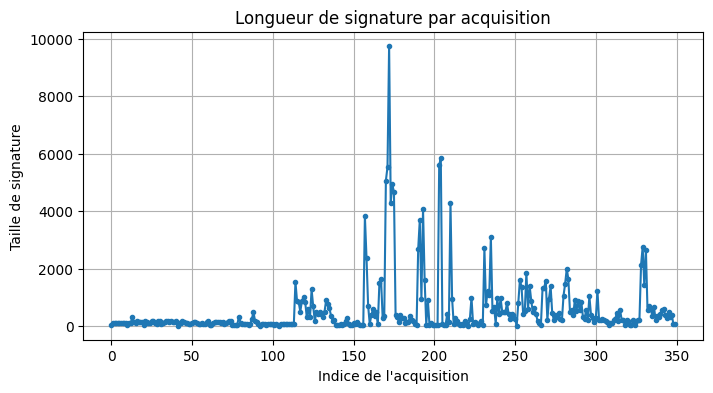

In [7]:
# AFFICHAGE DE LA TAILLE DES ACQUISITIONS EN FONCTION DE L'INDICE

# Taille de signature pour chaque acquisition
signature_lengths = [len(datas[i]["signature"]) for i in range(len(datas))]

# Statistiques
print(f"Min : {min(signature_lengths)}")
print(f"Max : {max(signature_lengths)}")
print(f"Moyenne : {np.mean(signature_lengths):.2f}")

# Tracé
plt.figure(figsize=(8, 4))
plt.plot(signature_lengths, marker='.')
plt.xlabel("Indice de l'acquisition")
plt.ylabel("Taille de signature")
plt.title("Longueur de signature par acquisition")
plt.grid(True)
plt.show()

## Structure du dataset

### Structure générale

- datas : `numpy.ndarray`
- Taille : `(350,)`
- Type : `object`

object = **dictionnaire Python** = une acquisition radar associée à une seule cible.

### Structure d'un élément

```python
datas[i]
```

Contient les clés suivantes :

```python
{
    "signature",
    "ts",
    "range_doppler_response",
    "class_name",
    "radar_parameters",
    "id"
}
```

---

### `class_name`

Label de la cible observée.

- `"vehicle"`
- `"bicycle"`
- `"human"`
- `"uav"`

Chaque acquisition est associée à une seule classe.

### `signature`

Signature radar complexe : Range-bin Doppler cut / Doppler profile at target range

```python
datas[i]["signature"].shape
# (len(), 1008)
```

Type :

```python
complex64
```

- Nombre mesures temporelles : Min : 11 / Max : 9757 / Moyenne : 535.41
- 1008 échantillons par mesure

### `ts`

Timestamps associés aux mesures.

```python
len(datas[i]["ts"])
# 44
```

- Nombre timestamps = Nombre mesures temporelles
- correspondance 1:1 avec les signatures
- pas = 0.05 s

### `range_doppler_response`

Réponse Range-Doppler pré-calculée.

Liste : 'range', 'azimuth', 'velocity', 'snr_db', 'x', 'y', 'z'

### `radar_parameters`

Paramètres du radar utilisés lors de l'acquisition.

Exemple :

```python
{
    "num_range_bins": 91.0,
    "num_pulses": 1008,
    "num_antenna_elements": 4,
    "fc": 7.827e10,
    "bw": ...,
    "prf": 33333.33,
    "element_spacing": 9.58e-4,
    "element_opening_angle": 160.0
}
```

Observations : Paramètres varient peu entre les acquisitions

### `id`

Identifiant unique de l'acquisition.

```python
datas[i]["id"]
```

---

## Résumé

```text
Dataset
└── 350 acquisitions radar

Acquisition i
├── class_name
├── signature                
├── ts                       
├── range_doppler_response
├── radar_parameters
└── id
```

In [8]:
# DATA SPLIT

all_indices = list(range(len(datas)))
train_indices, test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)

le = preprocessing.LabelEncoder()
le.fit_transform(class_names)

# for ind in train_indices:
train_signatures = [datas[i] for i in train_indices]
test_signatures = [datas[i] for i in test_indices]

#Count the Number of samples:
n_samples_train = 0
n_samples_test = 0
for signature in train_signatures:
    n_samples_train += len(signature['ts'])

for signature in test_signatures:
    n_samples_test += len(signature['ts'])


print("Train dataset size: " +str(n_samples_train))
print("Test dataset size: " +str(n_samples_test))

Train dataset size: 151455
Test dataset size: 35937


In [9]:
# FONCTION DE CONVERSION DES CLASSES EN ENTIER 

def conversion(class_name):
    for i in range(len(class_names)):
        if class_name == class_names[i]:
            return i

In [10]:
# FONCTION DE CREATION DES TENSORS

def tensor(L_indices):

    X = []
    y = []

    for i in L_indices:
    
        n_exp = len(datas[i]['signature']) // 10
    
        for k in range(n_exp):

            exp = datas[i]['signature'][10*k:10*(k+1)]
            X.append(exp)   

            y.append(conversion(datas[i]['class_name'])) 

    X = np.array(X)
    y = np.array(y)

    X = torch.tensor(X, dtype=torch.complex64)
    y = torch.tensor(y, dtype=torch.long)

    X = X.unsqueeze(1)      # Ajoute 1 dimension à l'indice 1

    return [X, y]


In [11]:
# CREATION DES TENSORS

X_train, y_train = tensor(train_indices)
X_test, y_test = tensor(test_indices)

print(f"Forme de X_train : {X_train.shape} -> (Batch, Channels, Height, Width)")
print(f"Forme de X_test : {X_test.shape} -> (Batch, Channels, Height, Width)")
print(f"Forme de y_train : {y_train.shape} -> (Batch)")
print(f"Forme de y_test : {y_test.shape} -> (Batch)")

Forme de X_train : torch.Size([15019, 1, 10, 1008]) -> (Batch, Channels, Height, Width)
Forme de X_test : torch.Size([3560, 1, 10, 1008]) -> (Batch, Channels, Height, Width)
Forme de y_train : torch.Size([15019]) -> (Batch)
Forme de y_test : torch.Size([3560]) -> (Batch)


---

### Fonctions des MLP

<u>Liste des fonctions :</u>

- Création des batchs
- Structure des réseaux de neurones
- Suivi training accuracy
- Training
- Affichage update ratio
- Test (loss & accuracy)
- Matrice de confusion

In [12]:
# CREATION DES BATCHS

def loader(X, y):
    
    dataset = TensorDataset(X, y)                                 
    loader = DataLoader(dataset, batch_size=50, shuffle=True, drop_last=True)

    return loader

In [13]:
# STRUCTURE DES RESEAUX DE NEURONES 


# -----------------------------------
# I -/ ARCHITECTURE DE BASE
# -----------------------------------


class CNN2D(nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=(3,3), stride=(1, 4), padding=(1,3), bias=False)
        self.b2d_1 = nn.BatchNorm2d(num_features=32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,4))

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding='same', bias=False)
        self.b2d_2 = nn.BatchNorm2d(num_features=64)
        self.gap = nn.AdaptiveAvgPool2d(1)      # Output size = 1 * 1

        self.fc1 = nn.Linear(in_features=64, out_features=250, bias=False)
        self.b1d = nn.BatchNorm1d(num_features=250)

        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(in_features=250, out_features=4)

    def forward(self, x):

        x = self.conv1(x)
        x = self.b2d_1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.b2d_2(x)
        x = F.relu(x)
        x = self.gap(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.b1d(x)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc_out(x)

        return x
    

# -----------------------------------
# II -/ ARCHITECTURE RESNET 2D
# -----------------------------------


class ResidualBlock(nn.Module):         # Residual Block -> conserve les dimensions (car out = out + identity)

    def __init__(self, in_channels, out_channels, stride=1, kernel_size=(3,3)):
        super().__init__()

        # Calcul automatique padding => garder les dimensions à stride=1
        kh, kw = kernel_size
        padding = ((kh - 1) // 2, (kw - 1) // 2)

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity        # Permet un meilleur apprentissage => circulation du gradient dans les premières couches 

        out = F.relu(out)

        return out
    

class ResNet2D(nn.Module):          # Downsampling -> entre les Residual Block

    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=(3,3), stride=(1, 4), padding=(1,3), bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = ResidualBlock(in_channels=32, out_channels=64, stride=1)
        self.block2 = ResidualBlock(64, 64, stride=(1, 2))

        self.pool = nn.MaxPool2d(kernel_size=(2,4)) 

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same', bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        self.block3 = ResidualBlock(64, 64, stride=(1,4))
        self.block4 = ResidualBlock(64, 64, stride=(1,4))

        self.gap = nn.AdaptiveAvgPool2d(1)      # Moyenne temporelle de tous les éléments au sein d'un canal (nombre moyen d'apparitions d'un motif)

        self.fc_out = nn.Linear(64, 4)

        self.dropout2d = nn.Dropout2d(p=0.2)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout2d(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2d(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)       # retirer les deux dernières dimensions 
        x = self.fc_out(x)

        return x


In [14]:
# FONCTION ACCURACY TRAINING

def accuracy(Model, loader):

    Model.eval()      

    correct = 0
    total = 0

    with torch.no_grad():
    
        for X_batch, y_batch in loader:

            # Transfert des datas vers le GPU :
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_predt = Model(X_batch)

            res_pred = y_predt.max(1).indices
            correct += (res_pred == y_batch).float().sum()
            total += y_batch.size(0)
        
        accuracy = (correct / total)*100
        
        return accuracy
        

In [15]:
# FONCTION DE TRAINING

criterion = nn.CrossEntropyLoss()

def training(Model, epochs, loader_train, loader_test):

    optimizer = optim.Adam(Model.parameters(), lr=0.001, weight_decay=1e-3)      

    update_ratios = []
    steps = []
    global_step = 0
    best_acc = 0
    patience_max = 30

    dico = {}

    for epoch in range(epochs):

        Model.train()
    
        for X_batch, y_batch in loader_train:

            # Transfert des datas vers le GPU :
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Foward pass : 
            y_pred = Model(X_batch)

            # Loss :
            loss = criterion(y_pred, y_batch)
            if global_step == 0:
                print(f"Premier loss = {loss.item():.4f}")
                dico["Premier loss"] = loss.item()

            # Reset Grad :
            optimizer.zero_grad()

            # Back pass :
            loss.backward()

            #Calcul des weights avant update
            with torch.no_grad():
                weights_before = Model.fc_out.weight.clone().cpu()

            # Update Weights :
            optimizer.step()
    
            # Diagnostique :
            with torch.no_grad():
                global_step +=1
                steps.append(global_step) 

                weights_after = Model.fc_out.weight.cpu()
                taille_pas = (weights_after - weights_before).abs().mean()
                update_ratio = torch.log10(taille_pas / weights_after.abs().mean() + 1e-8)
                update_ratios.append(update_ratio)

        # Test après chaque epoch => éviter l'overtraining
        current_acc = accuracy(Model, loader_test)
        print(f"Epoch {epoch:02d} | Loss Train: {loss.item():.4f} | Acc Test: {current_acc:.2f}%")
        
        if best_acc <= current_acc :
            best_acc = current_acc
            torch.save(Model.state_dict(), 'best_model.pth')
            patience_counter = 0
        else : 
            patience_counter += 1
        if patience_counter >= patience_max:
            print(f"\n Early stopping déclenché ! Pas d'amélioration depuis {patience_max} epochs.")
            print(f"Meilleur précision : {best_acc:.2f}")
            return fin_training(epoch, loss, steps, update_ratios, dico)
        

    return fin_training(epochs, loss, steps, update_ratios, dico)



def fin_training(epoch, loss, steps, update_ratios, dico):
    
    print(f"Dernier loss = {loss.item():.4f} obtenu à l'epoch = {epoch}")
    dico["Dernier loss"] = loss.item()
    dico["steps"] = steps
    dico["update_ratios"] = update_ratios

    return dico

In [16]:
# FONCTION AFFICHAGE DE L'UPDATE RATIO

def plot_update_ratio(steps, update_ratios):

    plt.figure(figsize=(8,5))
    plt.plot(steps, update_ratios)
    plt.axhline(-3, linestyle='--')
    plt.xlabel("Training step")
    plt.ylabel("log10(update/data)")
    plt.title("Update-to-Data Ratio")
    plt.grid(True)
    plt.show()

In [17]:
# FONCTION DE TEST

def Test(Model, loader):
    
    Model.eval()      # BatchNorm2d : running_mean & running_std / Stop Dropout

    correct = 0
    total = 0
    running_loss = 0
    n_batches = 0

    with torch.no_grad():
    
        for X_batch, y_batch in loader:

            # Transfert des datas vers le GPU :
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_predt = Model(X_batch)
            loss = criterion(y_predt, y_batch)
            running_loss += loss.item()
            n_batches += 1

            res_pred = y_predt.max(1).indices
            correct += (res_pred == y_batch).float().sum()
            total += y_batch.size(0)
        
        accuracy = correct / total
        print(f"Précision sur le Test : {accuracy.item() * 100:.2f} %")
        loss_test = running_loss / n_batches
        print(f"Test Loss : {loss_test:.6f}")

In [18]:
# FONCTION MATRICE DE CONFUSION

def Matrice_Confusion(Model, loader):
    
    Model.eval()      

    all_pred = []
    all_true = []

    with torch.no_grad():
    
        for X_batch, y_batch in loader:

            # Transfert des datas vers le GPU :
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_predt = Model(X_batch)
            pred = y_predt.argmax(dim=1)

            all_pred.extend(pred.cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())

    return confusion_matrix(all_true, all_pred, normalize=None)

            

---

### Premier cas d'étude : PUISSANCE

<u>Input :</u> 
- Puissance des spectres (dB -> log abs)

In [19]:
# CONVERSION EN dB

X_train_amp = torch.abs(X_train)
X_train_power_dB = 20*torch.log10(X_train_amp + 1e-12)

X_test_amp = torch.abs(X_test)
X_test_power_dB = 20*torch.log10(X_test_amp + 1e-12)

------------------| EXECUTION |------------------

In [20]:
# CHOIX D'EXECUTION DU MODELE

# 1 => architecture basique | 2 => architecture resnet
choix = 1

In [21]:
# CREATION DU RESEAU DE NEURONES + ENVOI SUR GPU

if choix == 1:
    model = CNN2D(in_channels=1).to(device)
elif choix == 2:
    model = ResNet2D(in_channels=1).to(device)

In [22]:
# TRAINING

dico = training(model, epochs=200, loader_train=loader(X_train_power_dB, y_train), loader_test=loader(X_test_power_dB, y_test)) 

Premier loss = 1.4777
Epoch 00 | Loss Train: 0.7726 | Acc Test: 63.41%
Epoch 01 | Loss Train: 0.6285 | Acc Test: 71.24%
Epoch 02 | Loss Train: 0.5483 | Acc Test: 68.11%
Epoch 03 | Loss Train: 0.6220 | Acc Test: 69.77%
Epoch 04 | Loss Train: 0.6097 | Acc Test: 36.20%
Epoch 05 | Loss Train: 0.6477 | Acc Test: 71.61%
Epoch 06 | Loss Train: 0.7609 | Acc Test: 70.48%
Epoch 07 | Loss Train: 0.6629 | Acc Test: 76.68%
Epoch 08 | Loss Train: 0.5390 | Acc Test: 65.75%
Epoch 09 | Loss Train: 0.4514 | Acc Test: 66.31%
Epoch 10 | Loss Train: 0.6009 | Acc Test: 47.46%
Epoch 11 | Loss Train: 0.4812 | Acc Test: 67.38%
Epoch 12 | Loss Train: 0.4408 | Acc Test: 73.49%
Epoch 13 | Loss Train: 0.4383 | Acc Test: 67.94%
Epoch 14 | Loss Train: 0.4145 | Acc Test: 74.03%
Epoch 15 | Loss Train: 0.4111 | Acc Test: 57.52%
Epoch 16 | Loss Train: 0.3386 | Acc Test: 74.56%
Epoch 17 | Loss Train: 0.4254 | Acc Test: 70.08%
Epoch 18 | Loss Train: 0.5202 | Acc Test: 75.69%
Epoch 19 | Loss Train: 0.5413 | Acc Test: 69.49

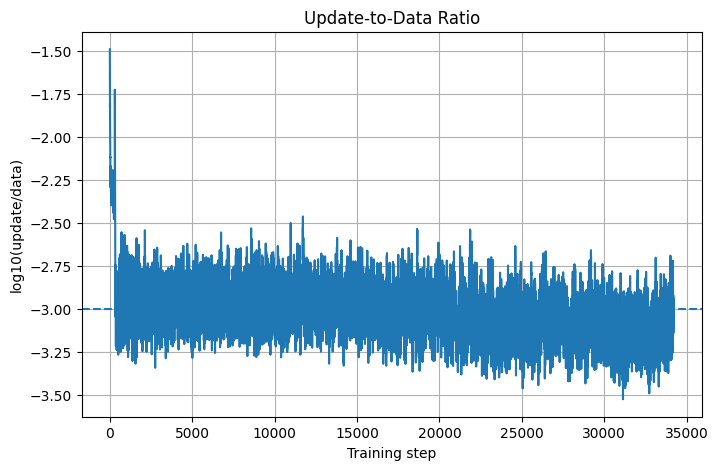

In [54]:
# AFFICHAGE DE L'UPDATE RATIO

plot_update_ratio(dico["steps"], dico["update_ratios"])

In [55]:
# TEST DU RESEAU

Test(model, loader=loader(X_test_power_dB, y_test))

Précision sur le Test : 83.61 %
Test Loss : 0.459859


---

### Deuxième cas d'étude : Re() & Im()

<u>Input :</u> 
- Size Dimension Channels = 2 (Re() & Im())

In [33]:
# EXTRACTION DES PARTIES REELLES ET IMAGINAIRES

X_train_real = torch.real(X_train)
X_train_imag = torch.imag(X_train)

X_test_real = torch.real(X_test)
X_test_imag = torch.imag(X_test)

# CONCATENATION -> FORMATION D'UN UNIQUE TENSOR 

X_train_RI = torch.cat([X_train_real, X_train_imag], dim=1)
X_test_RI = torch.cat([X_test_real, X_test_imag], dim=1)

# NORMALISATION

max_val = torch.amax(torch.abs(X_train_RI), dim=(2,3), keepdim=True)    # valeur max pour chaque batch (spectrogramme : (10, 1008))
X_train_RI_norm = X_train_RI / (max_val + 1e-12)                        # max_val.shape = (B,2,1,1) -> broadcasting -> (B,2,10,1008)
max_val = torch.amax(torch.abs(X_test_RI), dim=(2,3), keepdim=True)
X_test_RI_norm = X_test_RI / (max_val + 1e-12)

print(f"Shape X_train_RI = {X_train_RI_norm.shape}")
print(f"Shape X_test_RI = {X_test_RI_norm.shape}")

Shape X_train_RI = torch.Size([15019, 2, 10, 1008])
Shape X_test_RI = torch.Size([3560, 2, 10, 1008])


------------------| EXECUTION |------------------

In [34]:
# CHOIX D'EXECUTION DU MODELE

# 1 => architecture basique | 2 => architecture resnet
choix = 2

In [35]:
# CREATION DU RESEAU DE NEURONES + ENVOI SUR GPU

if choix == 1:
    model = CNN2D(in_channels=2).to(device)
elif choix == 2:
    model = ResNet2D(in_channels=2).to(device)

In [36]:
# TRAINING

dico = training(model, epochs=200, loader_train=loader(X_train_RI_norm, y_train), loader_test=loader(X_test_RI_norm, y_test))

Premier loss = 1.4638
Epoch 00 | Loss Train: 0.8169 | Acc Test: 53.41%
Epoch 01 | Loss Train: 0.7581 | Acc Test: 63.41%
Epoch 02 | Loss Train: 0.4924 | Acc Test: 65.10%
Epoch 03 | Loss Train: 0.7059 | Acc Test: 62.45%
Epoch 04 | Loss Train: 0.5325 | Acc Test: 66.06%
Epoch 05 | Loss Train: 0.4172 | Acc Test: 69.46%
Epoch 06 | Loss Train: 0.4968 | Acc Test: 69.52%
Epoch 07 | Loss Train: 0.3964 | Acc Test: 68.99%
Epoch 08 | Loss Train: 0.3638 | Acc Test: 68.70%
Epoch 09 | Loss Train: 0.6517 | Acc Test: 69.89%
Epoch 10 | Loss Train: 0.3721 | Acc Test: 70.14%
Epoch 11 | Loss Train: 0.3758 | Acc Test: 68.76%
Epoch 12 | Loss Train: 0.3542 | Acc Test: 70.79%
Epoch 13 | Loss Train: 0.3227 | Acc Test: 71.49%
Epoch 14 | Loss Train: 0.3722 | Acc Test: 70.20%
Epoch 15 | Loss Train: 0.3075 | Acc Test: 71.44%
Epoch 16 | Loss Train: 0.5037 | Acc Test: 70.59%
Epoch 17 | Loss Train: 0.2514 | Acc Test: 71.77%
Epoch 18 | Loss Train: 0.1922 | Acc Test: 71.69%
Epoch 19 | Loss Train: 0.3126 | Acc Test: 70.14

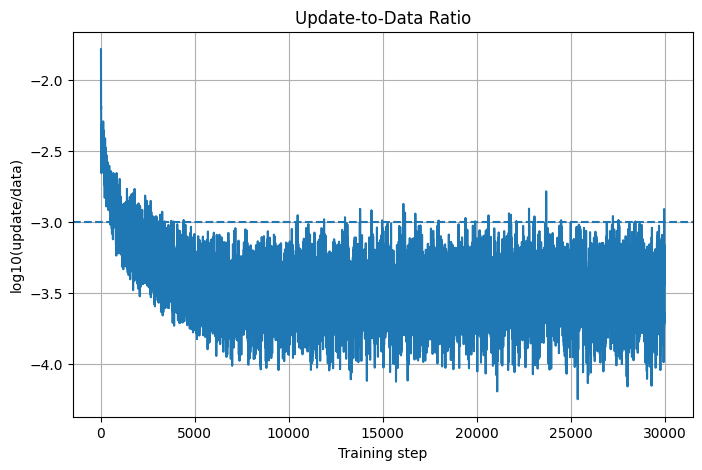

In [102]:
# AFFICHAGE DE L'UPDATE RATIO

plot_update_ratio(dico["steps"], dico["update_ratios"])

In [103]:
# TEST DU RESEAU

Test(model, loader=loader(X_test_RI_norm, y_test))

Précision sur le Test : 64.56 %
Test Loss : 1.416674


---

### Troisième cas d'étude : Amplitude & Phase

<u>Input :</u> 
- Size Dimension Channels = 2 (amplitude & phase)

In [27]:
# PREPARATION DES DATAS

X_train_mod = torch.abs(X_train)
X_test_mod = torch.abs(X_test)

X_train_phase = torch.angle(X_train)
X_test_phase = torch.angle(X_test)

X_train_AP = torch.cat([X_train_mod, X_train_phase], dim=1)
X_test_AP = torch.cat([X_test_mod, X_test_phase], dim=1)

print(f"Shape X_train_AP = {X_train_AP.shape}")
print(f"Shape X_test_AP = {X_test_AP.shape}")

Shape X_train_AP = torch.Size([15019, 2, 10, 1008])
Shape X_test_AP = torch.Size([3560, 2, 10, 1008])


------------------| EXECUTION |------------------

In [51]:
# CHOIX D'EXECUTION DU MODELE

# 1 => architecture basique | 2 => architecture resnet
choix = 2

In [52]:
# CREATION DU RESEAU DE NEURONES + ENVOI SUR GPU

if choix == 1:
    model = CNN2D(in_channels=2).to(device)
elif choix == 2:
    model = ResNet2D(in_channels=2).to(device)

In [53]:
# TRAINING

dico = training(model, epochs=110, loader_train=loader(X_train_AP, y_train), loader_test=loader(X_test_AP, y_test))

Premier loss = 1.5094
Epoch 00 | Loss Train: 0.4588 | Acc Test: 78.82%
Epoch 01 | Loss Train: 0.3163 | Acc Test: 81.69%
Epoch 02 | Loss Train: 0.2909 | Acc Test: 84.70%
Epoch 03 | Loss Train: 0.4209 | Acc Test: 82.42%
Epoch 04 | Loss Train: 0.1865 | Acc Test: 81.69%
Epoch 05 | Loss Train: 0.3943 | Acc Test: 83.15%
Epoch 06 | Loss Train: 0.0795 | Acc Test: 85.04%
Epoch 07 | Loss Train: 0.2167 | Acc Test: 84.62%
Epoch 08 | Loss Train: 0.0586 | Acc Test: 86.56%
Epoch 09 | Loss Train: 0.1767 | Acc Test: 80.54%
Epoch 10 | Loss Train: 0.1882 | Acc Test: 83.80%
Epoch 11 | Loss Train: 0.3601 | Acc Test: 80.48%
Epoch 12 | Loss Train: 0.2998 | Acc Test: 84.54%
Epoch 13 | Loss Train: 0.1877 | Acc Test: 86.54%
Epoch 14 | Loss Train: 0.1778 | Acc Test: 86.31%
Epoch 15 | Loss Train: 0.1227 | Acc Test: 87.01%
Epoch 16 | Loss Train: 0.1122 | Acc Test: 85.58%
Epoch 17 | Loss Train: 0.0275 | Acc Test: 82.37%
Epoch 18 | Loss Train: 0.1548 | Acc Test: 87.01%
Epoch 19 | Loss Train: 0.0886 | Acc Test: 82.68

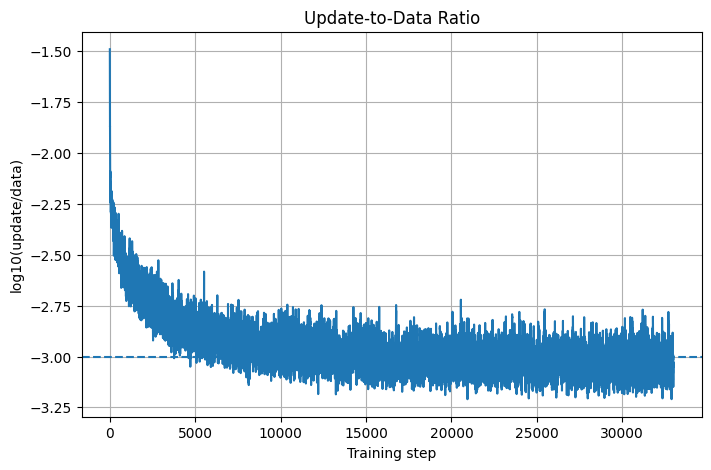

In [37]:
# AFFICHAGE DE L'UPDATE RATIO

plot_update_ratio(dico["steps"], dico["update_ratios"])

In [38]:
# TEST DU RESEAU

Test(model, loader=loader(X_test_AP, y_test))

Précision sur le Test : 71.27 %
Test Loss : 0.664376


---

## Bilan

- Synthèse des training & test
- matrice de confusion sur le best model

### Synthèse des Performances - Classification Radar

| Représentation de l'Input | Architecture Basique (CNN 2D) | Architecture ResNet 2D |
| :--- | :---: | :---: |
| **Puissance (dB)** | 84% - 85% *(sensible au MaxPool)* | 87% *(2 blocs)* 87.7% *(4 blocs)* |
| **Brut (Réel & Imaginaire)** | 67% | 72% |
| **Physique (Module & Phase)** | 88.7% *(2 blocs)* | **89%** *(4 blocs)* |


### Remarques Clés

* **Régularisation (Early Stopping & Checkpoint) :** Outil critique du pipeline. La sauvegarde du meilleur modèle à son pic évite l'effondrement massif de la précision dû au surapprentissage tardif.
* **Apprentissage de Représentation (Module & Phase) :** Victoire de l'intuition physique. À volume d'information égal avec le cas Réel/Imaginaire, la forme polaire expose des gradients temporels spatiaux évidents ($\Delta \phi / \Delta t$), ce qui donne un accès direct et lisible au Doppler instantané pour les filtres CNN.
* **Apport du ResNet :** Gain constant de +3% à +5% de précision par rapport au CNN linéaire classique. Sa profondeur aide à décoder les géométries complexes et non linéaires des signaux bruts.

In [ ]:
# RECUPERATION DU BEST MODEL

# Étape 1 : Réinstancier l'architecture
best_mlp = ResNet2D(in_channels=2).to(device)

# Étape 2 : Chargement du dictionnaire de paramètres (disque dur -> VRAM)
paramètres = torch.load('best_model.pth', map_location=device)

# Étape 3 : Injectes des paramètres dans l'architecture 
best_mlp.load_state_dict(paramètres)

<All keys matched successfully>

In [ ]:
# VERIFICATION DU CHARGEMENT DU MODEL

Test(best_mlp, loader=loader(X_test_AP, y_test))

Précision sur le Test : 89.18 %
Test Loss : 0.353613


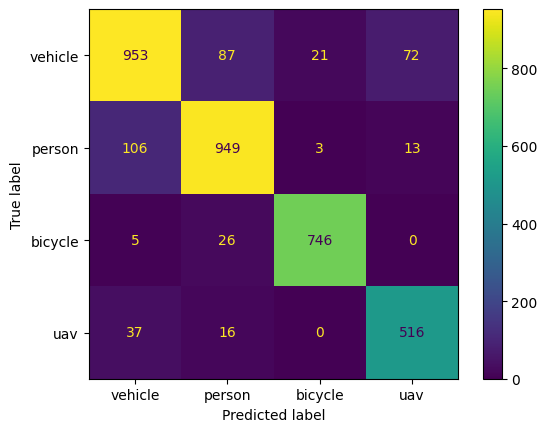

In [48]:
# MATRICE DE CONFUSION

cm_array = Matrice_Confusion(best_mlp, loader(X_test_AP, y_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot()

plt.show()